In [396]:
import pandas as pd
import numpy as np
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [397]:
full = pd.read_csv('../dataset/final_eda.csv')

In [398]:
received = (
    full.loc[full['event'] == 'offer received', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_received'})
    .sort_values(['customer_id', 'offer_id', 't_received'])
    .reset_index(drop=True)
)
viewed = (
    full.loc[full['event'] == 'offer viewed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_viewed'})
    .sort_values(['customer_id', 'offer_id', 't_viewed'])
    .reset_index(drop=True)
)
completed = (
    full.loc[full['event'] == 'offer completed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_completed'})
    .sort_values(['customer_id', 'offer_id', 't_completed'])
    .reset_index(drop=True)
)

# 같은 고객, 같은 오퍼를 수신 받았을 때 instance_id 각각 부여 (모두 1로, 똑같은 객체가 들어오면 그때 2)
received['instance_id'] = received.groupby(['customer_id', 'offer_id']).cumcount() + 1

portfolio_dur = (
    full[['offer_id', 'duration']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
received = received.merge(portfolio_dur, on='offer_id', how='left')

# [경계조건] t_expire = t_received + duration * 24
# - transcript.time 단위: 시간(hour), portfolio.duration 단위: 일(day) → *24 변환
# - 경계: t_received <= event_time <= t_expire (양 끝 포함, closed interval)
#   → 수신 시각과 만료 시각 정확히 일치하는 이벤트도 유효로 처리
#   → strict (<) 버전은 사용하지 않음 (수신 즉시 이벤트 발생 사례 존재)
received['t_expire'] = received['t_received'] + received['duration'] * 24

recv_keys = received[['customer_id', 'offer_id', 't_received', 'instance_id', 't_expire']]

In [399]:
def interval_join(events_df, event_time_col):
    # [경계조건] t_received <= t_event <= t_expire (양 끝 포함)
    # [ambiguous match 처리 규칙]
    #   - 같은 이벤트가 복수의 수신 구간에 걸칠 경우(ambiguous_match=1),
    #     t_received가 가장 최근인(=직전에 수신된) instance를 선택
    #   - 근거: 가장 최근 수신 오퍼에 반응했을 가능성이 가장 높다고 가정
    events_df = events_df.copy()
    events_df['_row_id'] = range(len(events_df))
    merged = events_df.merge(recv_keys, on=['customer_id', 'offer_id'], how='left') # 겹치는게 엄청 많을 거임 on 조건이 인스턴스 조건 뿐이므로!
    valid = merged[ # 하지만 여기서 필터링을 걸어줘서 구간 내에 포함되는 view와 receive 행만 추출
        (merged['t_received'] <= merged[event_time_col]) &
        (merged[event_time_col] <= merged['t_expire'])
    ].copy()
    match_cnt = ( # 같은 view 행에서 몇개의 receive 행이 연결되었는지 카운트
        valid.groupby('_row_id')['instance_id']
        .count().reset_index(name='match_count')
    )
    valid = valid.merge(match_cnt, on='_row_id')
    valid['ambiguous_match'] = (valid['match_count'] > 1).astype(int)
    valid = (
        valid.sort_values('t_received', ascending=False) # 같은 구간내에 여러개의 수신 인스턴스가 존재한다면 최근 수신된 인스턴스 선택
        .drop_duplicates(subset='_row_id', keep='first')
        .drop(columns='_row_id')
    )
    return valid

view_map = interval_join(viewed, 't_viewed')
comp_map = interval_join(completed, 't_completed')


In [400]:
view_map = view_map.sort_values(by=['customer_id','offer_id'])
view_map

,customer_id,offer_id,t_viewed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,informational,336,1,432.0,1,0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,informational,168,1,240.0,1,0
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,456,bogo,408,1,528.0,1,0
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,540,discount,504,1,744.0,1,0
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,630,bogo,576,2,696.0,1,0
...,...,...,...,...,...,...,...,...,...
58929,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,582,discount,576,3,744.0,1,0
58928,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
58926,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,354,discount,336,1,504.0,1,0
58930,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,534,bogo,504,1,672.0,1,0


In [401]:
comp_map = comp_map.sort_values(by=['customer_id','offer_id'])
comp_map

,customer_id,offer_id,t_completed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,576,1,744.0,1,0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,bogo,408,1,528.0,1,0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,discount,504,1,744.0,1,0
3,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,discount,408,1,648.0,1,0
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,discount,168,1,336.0,1,0
...,...,...,...,...,...,...,...,...,...
35373,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,576,3,744.0,2,1
35371,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
35369,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,discount,336,1,504.0,1,0
35374,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,504,1,672.0,1,0


In [402]:
# == [품질 체크 1] 이벤트 중복 매핑 확인 ==
dup_view_map = view_map[view_map.duplicated()]
print(f"중복건: {len(dup_view_map)}개") # 중복 없음

dup_comp_map = comp_map[comp_map.duplicated()]
print(f"중복건: {len(dup_comp_map)}개") # 중복 존재

중복건: 0개
중복건: 397개


In [403]:
n_no_match_v = len(viewed) - len(view_map)
n_no_match_c = len(completed) - len(comp_map)
n_ambig_v = view_map['ambiguous_match'].sum()
n_ambig_c = comp_map['ambiguous_match'].sum()
print(f"열람: 유효 구간 밖 {n_no_match_v:,}건 / ambiguous {n_ambig_v:,}건") # 한 view 행이 여러 receive 행과 연결될 수 있는 모호한 건 수
print(f"완료: 유효 구간 밖 {n_no_match_c:,}건 / ambiguous {n_ambig_c:,}건") # 한 complete 행이 여러 receive 행과 연결될 수 있는 모호한 건 수

view_summary = (
    view_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_viewed=('t_viewed', 'min'),
        last_viewed=('t_viewed', 'max'),
        view_count=('t_viewed', 'count'),
        view_ambiguous=('ambiguous_match', 'max')
    )
)

comp_summary = (
    comp_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_completed=('t_completed', 'min'),
        last_completed=('t_completed', 'max'),
        complete_count=('t_completed', 'count'),
        comp_ambiguous=('ambiguous_match', 'max')
    )
)

열람: 유효 구간 밖 1,158건 / ambiguous 2,339건
완료: 유효 구간 밖 0건 / ambiguous 1,776건


In [404]:
view_summary[view_summary['view_count']>1]

,customer_id,offer_id,instance_id,first_viewed,last_viewed,view_count,view_ambiguous


In [405]:
comp_summary[(comp_summary['complete_count']>1)&(comp_summary['first_completed']!=comp_summary['last_completed'])]

,customer_id,offer_id,instance_id,first_completed,last_completed,complete_count,comp_ambiguous
294,0246e7cc7a3d4a98a940cb13776b5b55,fafdcd668e3743c1bb461111dcafc2a4,2,582,624,2,1
505,041fd7c6b796430a867c4e03d2ff8f4d,0b1e1539f2cc45b7b9fa7c272da2e1d7,3,648,702,2,1
745,05e6bcb70fe14e0da4730527ca35a4ae,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,510,540,2,1
754,05f4d69f73024172a23a350e611166b4,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,414,432,2,1
904,072290a7410e49d3a1e45a89c92c58f3,2298d6c36e964ae4a3e7e9706d1fb8c2,2,432,468,2,1
...,...,...,...,...,...,...,...
30753,edc7b04392144da9979f3077095f268a,fafdcd668e3743c1bb461111dcafc2a4,3,474,498,2,1
31489,f3934f05d51f47c7a470661cbb774075,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,456,462,2,1
31996,f74033a8c6834303bd1b3ef0c98d11d8,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,576,714,2,1
31999,f7465d18ba7f4e43b99ccabf141d421d,2906b810c7d4411798c6938adc9daaa5,3,504,594,2,1


In [406]:
# == [품질 체크 2] 이벤트 중복 매핑 & tie-break 확인 ==

# 1. 한 이벤트가 여러 instance에 중복 매핑되지 않는지
dup_view = view_summary.duplicated().sum()
dup_comp = comp_summary.duplicated().sum()
print(f"[중복 매핑] view_summary: {dup_view}건 / comp_summary: {dup_comp}건 (0이어야 정상)")
assert dup_view == 0, f'view_map 중복 매핑 {dup_view}건 존재'
assert dup_comp == 0, f'comp_summary 중복 매핑 {dup_comp}건 존재'

print("\n✓ 중복 매핑 체크 통과 \n")

# 2. ambiguous match 건수 확인 (tie-break: 최근 t_received 기준 1개 선택)
ambig_v = view_summary['view_ambiguous'].sum()
ambig_c = comp_summary['comp_ambiguous'].sum()
print(f"[Ambiguous match] view: {ambig_v:,}건 / comp: {ambig_c:,}건 → 최근 수신 instance 선택")

"""
[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)
[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택

✓ 중복 매핑 체크 통과
"""

[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)

✓ 중복 매핑 체크 통과 

[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택


'\n[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)\n[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택\n\n✓ 중복 매핑 체크 통과\n'

In [407]:
funnel_instance = (
    received.merge(view_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
            .merge(comp_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
)

funnel_instance['gap_to_first_view'] = funnel_instance['first_viewed'] - funnel_instance['t_received']
funnel_instance['gap_to_first_complete'] = funnel_instance['first_completed'] - funnel_instance['t_received']
funnel_instance['is_viewed'] = funnel_instance['first_viewed'].notna().astype(int)
funnel_instance['is_completed'] = funnel_instance['first_completed'].notna().astype(int)
funnel_instance['completed_without_prior_view'] = (
    (funnel_instance['is_completed'] & ~funnel_instance['is_viewed'])
    | (funnel_instance['first_completed'] < funnel_instance['first_viewed'])  # 완료가 열람보다 먼저인 경우
).astype(int)
funnel_instance['completed_with_prior_view'] = (
    funnel_instance['is_completed'] & funnel_instance['is_viewed']
    & (funnel_instance['first_viewed'] < funnel_instance['first_completed'])
).astype(int)

# prior view가 있고 시간 순서가 맞는 경우에만 gap 계산 (시간 순서 확실한 것만)
mask = (
    funnel_instance['first_viewed'].notna() &
    funnel_instance['first_completed'].notna() &
    (funnel_instance['first_viewed'] < funnel_instance['first_completed'])
)
funnel_instance['gap_first_view_to_first_complete'] = np.where(
    mask,
    funnel_instance['first_completed'] - funnel_instance['first_viewed'],
    np.nan
)

In [408]:
first_viewed_instance = ( # 같은 오퍼를 여러번 받은 경우 이벤트를 '열람'한 오퍼
    funnel_instance[funnel_instance['is_viewed']==1]
    .groupby(['customer_id','offer_id'])['instance_id']
    .min()
    .reset_index(name = 'first_viewed_instance')
)

first_viewed_instance['first_viewed_instance'].value_counts() # 경향만 보는 것으로!

first_viewed_instance
1    47024
2     1146
3       42
4        1
Name: count, dtype: int64

In [409]:
funnel_instance.sort_values(by=['customer_id','offer_id','instance_id'])

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,0,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,0,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,0,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,0,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,336,discount,1,7.0,504.0,354.0,354.0,1.0,0.0,384.0,384.0,1.0,0.0,18.0,48.0,1,1,0,1,30.0
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,414.0,414.0,1.0,1.0,414.0,414.0,1.0,1.0,6.0,6.0,1,1,0,0,NaN
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,3,7.0,744.0,582.0,582.0,1.0,0.0,576.0,576.0,1.0,1.0,6.0,0.0,1,1,1,0,NaN
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,1,7.0,672.0,534.0,534.0,1.0,0.0,504.0,504.0,1.0,0.0,30.0,0.0,1,1,1,0,NaN


In [410]:
funnel_instance.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_id                       76277 non-null  str    
 1   offer_id                          76277 non-null  str    
 2   t_received                        76277 non-null  int64  
 3   offer_type                        76277 non-null  str    
 4   instance_id                       76277 non-null  int64  
 5   duration                          76277 non-null  float64
 6   t_expire                          76277 non-null  float64
 7   first_viewed                      56567 non-null  float64
 8   last_viewed                       56567 non-null  float64
 9   view_count                        56567 non-null  float64
 10  view_ambiguous                    56567 non-null  float64
 11  first_completed                   33101 non-null  float64
 12  last_completed 

In [411]:
print(f"\n전체 오퍼 received 인스턴스 수: {len(funnel_instance):,}건")
print("\n[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]")
v = funnel_instance['gap_to_first_view'].dropna()
print(f"  평균   : {v.mean():.1f}시간 ({v.mean()/24:.1f}일)")
print(f"  중앙값 : {v.median():.1f}시간 ({v.median()/24:.1f}일)")
print(f"  6시간 내 열람 : {(v <= 6).mean()*100:.1f}%")
print(f"  24시간 내 열람: {(v <= 24).mean()*100:.1f}%")
print(f"  48시간 내 열람: {(v <= 48).mean()*100:.1f}%")

print("\n[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]")
c = funnel_instance['gap_to_first_complete'].dropna()
print(f"  평균   : {c.mean():.1f}시간 ({c.mean()/24:.1f}일)")
print(f"  중앙값 : {c.median():.1f}시간 ({c.median()/24:.1f}일)")
print(f"  1일 내 완료: {(c <= 24).mean()*100:.1f}%")
print(f"  3일 내 완료: {(c <= 72).mean()*100:.1f}%")
print(f"  7일 내 완료: {(c <= 168).mean()*100:.1f}%")

print("\n[ 퍼널 요약 ]")
print(f"  Viewed rate     : {funnel_instance['is_viewed'].mean()*100:.1f}%")
print(f"  Completed rate  : {funnel_instance['is_completed'].mean()*100:.1f}%")
print(f"  완료했지만 미열람: {funnel_instance['completed_without_prior_view'].mean()*100:.1f}%")


전체 오퍼 received 인스턴스 수: 76,277건

[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]
  평균   : 24.4시간 (1.0일)
  중앙값 : 12.0시간 (0.5일)
  6시간 내 열람 : 38.5%
  24시간 내 열람: 67.3%
  48시간 내 열람: 85.2%

[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]
  평균   : 61.2시간 (2.5일)
  중앙값 : 48.0시간 (2.0일)
  1일 내 완료: 31.2%
  3일 내 완료: 66.8%
  7일 내 완료: 96.7%

[ 퍼널 요약 ]
  Viewed rate     : 74.2%
  Completed rate  : 43.4%
  완료했지만 미열람: 12.9%


In [412]:
funnel_instance.head(10)

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,0,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,0,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,0,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,0,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,0,NaN
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,168,bogo,1,5.0,288.0,216.0,216.0,1.0,0.0,NaN,NaN,NaN,NaN,48.0,NaN,1,0,0,0,NaN
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,576,bogo,2,5.0,696.0,630.0,630.0,1.0,0.0,NaN,NaN,NaN,NaN,54.0,NaN,1,0,0,0,NaN
7,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,408,discount,1,10.0,648.0,432.0,432.0,1.0,0.0,576.0,576.0,1.0,0.0,24.0,168.0,1,1,0,1,144.0
8,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,168,discount,1,7.0,336.0,186.0,186.0,1.0,0.0,252.0,252.0,1.0,0.0,18.0,84.0,1,1,0,1,66.0
9,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,0,informational,1,4.0,96.0,6.0,6.0,1.0,0.0,NaN,NaN,NaN,NaN,6.0,NaN,1,0,0,0,NaN


In [413]:
funnel_instance.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 'first_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 'first_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_first_view', 'gap_to_first_complete',
       'is_viewed', 'is_completed', 'completed_without_prior_view',
       'completed_with_prior_view', 'gap_first_view_to_first_complete'],
      dtype='str')

In [414]:
print("received 원건수:", len(received))
print("instance funnel 원건수:", len(funnel_instance))

received 원건수: 76277
instance funnel 원건수: 76277


In [415]:
print("Viewed rate:", funnel_instance['is_viewed'].mean()) # 오퍼 노출은 잘 된다 (0.74)
print("Completed rate:", funnel_instance['is_completed'].mean()) # 전환에서 크게 떨어진다 (0.43)
print("Completed without prior view:", (funnel_instance['completed_without_prior_view']).mean()) # 사용자가 오퍼를 안 보고도 조건을 충족해서 reward를 받음

Viewed rate: 0.7415996958454055
Completed rate: 0.4339578116601335
Completed without prior view: 0.12892483972888288


In [416]:
# 중복확인
funnel_instance[['customer_id','offer_id','instance_id']].duplicated().sum()

np.int64(0)

In [417]:
funnel_instance.groupby('offer_type')[['is_viewed', 'is_completed', 'gap_to_first_view', 'gap_to_first_complete', 'gap_first_view_to_first_complete']].mean()

,is_viewed,is_completed,gap_to_first_view,gap_to_first_complete,gap_first_view_to_first_complete
offer_type,,,,,
bogo,0.827896,0.508246,23.815842,49.562609,41.922873
discount,0.699669,0.576237,25.832007,71.402386,58.716480
informational,0.652904,0.000000,22.610837,NaN,NaN


In [418]:
funnel_instance.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,0,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,0,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,0,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,0,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,0,NaN


In [419]:
# 이후 셀 참조명 통일 (first_ → 단축명) + completed_funnel_instance 재생성
funnel_instance = funnel_instance.rename(columns={
    'first_viewed':                         't_viewed',
    'first_completed':                      't_completed',
    'gap_to_first_view':                    'gap_to_view',
    'gap_to_first_complete':                'gap_to_complete',
    'gap_first_view_to_first_complete':     'gap_view_to_complete'
})
completed_funnel_instance = funnel_instance[funnel_instance['is_completed']==1].copy()

In [420]:
funnel_instance.to_csv('../dataset/funnel_instance.csv', index=False)

### 퍼널 인스턴스 데이터프레임 생성 완료 (인스턴스별)
### -> 다음 : 오퍼와 고객 정보 포함한 데이터프레임 생성

In [421]:
full = pd.read_csv('../dataset/final_eda.csv')
funnel = pd.read_csv('../dataset/funnel_instance.csv')

데이터 병합 시 validate 파라미터 값
- 'm:1' → 왼쪽은 중복 가능, 오른쪽은 반드시 unique
- '1:1' → 양쪽 모두 unique
- '1:m' → 왼쪽 unique, 오른쪽 중복 가능

In [422]:
# offer_id가 unique여야 하므로 validate='m:1' 검사
offer = ( # distinct offer_id
    full[['offer_id', 'reward', 'difficulty',
          'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
funnel = funnel.merge(offer, on='offer_id', how='left', validate='m:1')

# customer_id가 unique여야 하므로 validate='m:1' 검사
cust_attr = ( # distinct customer_id
    full[['customer_id', 'gender', 'age_group', 'income_group',
          'join_year', 'join_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)

print(f"병합 전 퍼널 데이터 행 개수: {len(funnel)}")
funnel = funnel.merge(cust_attr, on='customer_id', how='left', validate='m:1')
print(f"병합 후 퍼널 데이터 행 개수: {len(funnel)}") # 데이터 증폭 미발생 확인 완료

병합 전 퍼널 데이터 행 개수: 76277
병합 후 퍼널 데이터 행 개수: 76277


In [423]:
funnel.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,0,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,0,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,0,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,0,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


In [424]:
funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   76277 non-null  str    
 1   offer_id                      76277 non-null  str    
 2   t_received                    76277 non-null  int64  
 3   offer_type                    76277 non-null  str    
 4   instance_id                   76277 non-null  int64  
 5   duration                      76277 non-null  float64
 6   t_expire                      76277 non-null  float64
 7   t_viewed                      56567 non-null  float64
 8   last_viewed                   56567 non-null  float64
 9   view_count                    56567 non-null  float64
 10  view_ambiguous                56567 non-null  float64
 11  t_completed                   33101 non-null  float64
 12  last_completed                33101 non-null  float64
 13  complete_cou

In [425]:
# === [품질 체크 3] informational offer completed 여부 ===
info_completed = funnel[
    (funnel['offer_type'] == 'informational') & funnel['is_completed']
]
print(f"[Informational completed] {len(info_completed)}건 (0이어야 정상)")
assert len(info_completed) == 0, f'informational offer에 completed {len(info_completed)}건 존재'
print("✓ informational completed 체크 통과")

[Informational completed] 0건 (0이어야 정상)
✓ informational completed 체크 통과


# 5대 지표 생성
| 변수 | 한글 명칭 | 의미 |
|---|---|---|
| `view_rate` | 열람율 | 전체 수신 건 중 열람 비율 |
| `complete_rate` | 완료율 (최종 전환율) | 전체 수신 건 중 완료 비율 |
| `view_cvr` | 열람후 완료율 | 열람한 건 중 오퍼 열람 후 완료 비율 |
| `eff_cvr` | 인지 완료율 | 완료된 건 중 오퍼 열람 후 완료 비율 |
| `non_eff_cvr` | 미인지 완료율 | 완료된 건 중 오퍼를 미열람 후 완료 비율 |

In [426]:
# 5대 지표 생성 함수
def funnel_metrics(df, group_col: str = "offer_type"):
    return (
        df.groupby(group_col)
        .agg(
            received            = ("instance_id",                  "count"),
            viewed              = ("is_viewed",                    "sum"),
            completed           = ("is_completed",                 "sum"),
            aware_completed     = ("completed_with_prior_view",    "sum"),
            non_aware_completed = ("completed_without_prior_view", "sum"),
        )
        .assign(
            view_rate     = lambda d: d["viewed"]              / d["received"],
            complete_rate = lambda d: d["completed"]           / d["received"],
            view_cvr      = lambda d: d["aware_completed"]     / d["viewed"],
            eff_cvr       = lambda d: d["aware_completed"]     / d["completed"],
            no_eff_cvr    = lambda d: d["non_aware_completed"] / d["completed"],
        )
        .reset_index()
    )

In [427]:
# 5대 지표 함수 사용 예시
df1 = funnel_metrics(funnel, "income_group")
df2 = funnel_metrics(funnel, "channel_count")
df3 = funnel_metrics(funnel, "age_group")

### 세그먼트별 분석

### 채널별/채널수별 분석

In [428]:
df = funnel.copy()

In [429]:
analysis_df = funnel_metrics(funnel, ['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count'])
analysis_df

,ch_web,ch_email,ch_mobile,ch_social,channel_count,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
0,0.0,1.0,1.0,1.0,3.0,15276,12828,3635,2242,1053,0.839749,0.237955,0.174774,0.616781,0.289684
1,1.0,1.0,0.0,0.0,2.0,7668,2652,3313,1217,2013,0.345853,0.432055,0.458899,0.367341,0.607606
2,1.0,1.0,1.0,0.0,3.0,22926,11987,8258,3712,4050,0.522856,0.360202,0.309669,0.449504,0.490434
3,1.0,1.0,1.0,1.0,4.0,30407,29100,17895,13377,2718,0.957016,0.588516,0.459691,0.747527,0.151886


#### 통계검정

In [430]:
# 채널수와 시간에 관한 통계검정
# Kruskal-Wallis 검정 수행 (stats.kruskal) 함수 (사후검정 포함)
from scipy import stats
import scikit_posthocs as sp

def kruskal(group_a, group_b, group_c):
    h_stat, kw_p = stats.kruskal(group_a, group_b, group_c)
    print(f"  H 통계량: {h_stat:.4f}")
    print(f"  p-value: {kw_p:.4f}")

    # η²_H 효과크기 계산
    # 공식: η²_H = (H − k + 1) / (N − k)  (k=집단수, N=전체 표본 크기)
    k = 3
    N = len(group_a) + len(group_b) + len(group_c)
    eta_sq_h = (h_stat - k + 1) / (N - k)

    if h_stat is not None:
        print(f"  H 통계량: {h_stat:.4f}")
        print(f"  p-value: {kw_p:.4f}")

    if eta_sq_h is not None:
        size_eta = '작은' if eta_sq_h < 0.06 else '중간' if eta_sq_h < 0.14 else '큰'
        print(f"\n  [효과크기] η²_H = {eta_sq_h:.4f} ({size_eta} 효과)")

    if kw_p is not None:
        verdict = 'H₀ 기각: 유의한 차이가 있습니다' if kw_p < 0.05 else 'H₀ 기각 실패: 유의한 차이가 없습니다'
        print(f"  판정: {verdict}")    


    # Kruskal-Wallis에 대한 사후 검정 : Dunn Test
    if kw_p is not None and kw_p < 0.05:
        print(f"\nDunn 사후검정 (Holm 보정)")
        print("=" * 60)
        data_list = [group_a, group_b, group_c]

        # Dunn's Test 수행 (p_adjust는 다중 비교 보정을 위해 'holm' 혹은 'bonferroni' 사용) --> holm이 검정력이 더 좋은 경향!
        # 결과는 행렬 형태로 반환
        dunn = sp.posthoc_dunn(data_list, p_adjust='holm')

        # 인덱스와 컬럼명을 보기 좋게 변경
        dunn.columns = ['2개', '3개', '4개']
        dunn.index = ['2개', '3개', '4개']

        display(dunn.round(4))

        # 중앙값 계산
        # 시간(Gap) 데이터는 이상치가 많기 때문에 비모수 검정 결과의 방향성을 설명할 땐 평균보다 중앙값이 더 적절함
        group_names = dunn.columns.tolist() # ['2개', '3개', '4개']
        medians = {name: np.median(data) for name, data in zip(group_names, data_list)}

        # 쌍별 비교 및 방향성 해석
        for i in range(len(group_names)):
            for j in range(i + 1, len(group_names)):
                g1, g2 = group_names[i], group_names[j]
                data1, data2 = data_list[i], data_list[j] # 실제 데이터 추출

                p_val = dunn.loc[g1, g2]
                sig = "유의한 차이 있음" if p_val < 0.05 else "차이 없음"

                # 쌍별 효과 크기(Rank-Biserial r) 계산 ──
                u_stat, _ = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                n1, n2 = len(data1), len(data2)
                r_val = abs(1 - (2 * u_stat) / (n1 * n2)) # 절대값으로 크기 표현
                
                # 효과 크기 해석
                r_size = '작음' if r_val < 0.3 else '중간' if r_val < 0.5 else '큼'

                m1, m2 = medians[g1], medians[g2]
                
                # 시간(Gap) 데이터는 '낮을수록' 빠른 것이므로 해석에 주의!
                if m1 > m2:
                    direction = f"{g2}({m2:.1f}h)가 {g1}({m1:.1f}h)보다 더 빠릅니다"
                elif m1 < m2:
                    direction = f"{g1}({m1:.1f}h)가 {g2}({m2:.1f}h)보다 더 빠릅니다"
                else:
                    direction = "두 집단의 반응 속도가 동일합니다"

                print(f"  [{g1} vs {g2}] {sig} (p={p_val:.4f})")
                print(f"    → 효과 크기(r): {r_val:.4f} ({r_size} 수준)")
                print(f"    → {direction}")
                print("-" * 30)

In [431]:
# 채널 활용 유무에 관한 통계검정
# Mann-Whitney U검정 함수
def mann(group_a, group_b):

    # alternative='less': 소셜 그룹의 gap(시간)이 더 '작다(빠르다)'는 가설을 검정
    u_stat, p_val = stats.mannwhitneyu(group_a, group_b, alternative='less')

    # 효과 크기(Rank-Biserial Correlation) 계산
    # r = 1 - (2 * U) / (n1 * n2)
    n1, n2 = len(group_a), len(group_b)
    effect_size_r = 1 - (2 * u_stat) / (n1 * n2)

    print(f"\nMann-Whitney U 검정 결과")
    print("=" * 60)
    print(f"  U 통계량: {u_stat:.2f}")
    print(f"  p-value: {p_val:.4f}")
    print(f"  효과 크기(r): {effect_size_r:.4f}")

    # 결과 해석
    if p_val < 0.05:
        print(f"\n👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.")
        if effect_size_r > 0.5: 
            print(f"효과크기 큼: 매우 강력한 차이")
        elif effect_size_r > 0.3:
            print(f"효과크기 중간: 실무적으로 유의미한 차이")
        elif effect_size_r > 0.1:
            print(f"효과크기 작음: 체감도 낮은 차이")
        else:
            print(f"효과크기 미미: 무시해도 될만한 차이")
    else:
        print(f"\n👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.")

In [432]:
# 채널 활용 유무와 열람률/완료율/인지후 완료율 등 비율 통계검정: 카이제곱 독립성 검정
def chi2(ct):
    r, c = ct.shape # 행, 열 수
    chi2_ind, p_ind, dof_ind, expected_ind = stats.chi2_contingency(ct)

    # ── 기대빈도 조건 확인 (Cochran's rule) ──
    expected_df = pd.DataFrame(expected_ind, index=ct.index, columns=ct.columns)
    # display(expected_df.round(1))

    # Cochran's rule: (1) E<5인 셀이 20% 이하 AND (2) E<1인 셀이 0개
    # 충족한다

    # p-value
    if p_ind < 0.05: 
        print(f"\np-value: {p_ind:.4f}")
        print("귀무가설 기각 -> 두 변수는 연관성이 있다")

        # ── Cramér's V (효과 크기) ──
        df_star = min(r-1, c-1)
        n_total = ct.values.sum()
        cramers_v = np.sqrt(chi2_ind / (n_total*df_star))
        print(f"효과크기: {cramers_v:.4f}") 
        if cramers_v > 0.5: 
            print(f"효과크기 큼: 매우 강력한 연관성")
        elif cramers_v > 0.3:
            print(f"효과크기 중간: 실무적으로 유의미한 연관성")
        elif cramers_v > 0.1:
            print(f"효과크기 작음: 체감도 낮은 연관성")
        else:
            print(f"효과크기 미미: 무시해도 될만한 연관성")
            
    else:
        print(f"\np-value: {p_ind:.4f}")
        print("귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)")

#### 열람까지 걸리는 시간

In [433]:
# 채널수와 열람까지 걸리는 시간 관계 비교 : Kruskal-Wallis 검정

print(f"\nKruskal-Wallis 검정: 채널수에 따른 열람까지 걸리는 시간 차이")
print("=" * 60)

group2 = df[df['channel_count'] == 2]['gap_to_view'].dropna()
group3 = df[df['channel_count'] == 3]['gap_to_view'].dropna()
group4 = df[df['channel_count'] == 4]['gap_to_view'].dropna()

kruskal(group2, group3, group4)


Kruskal-Wallis 검정: 채널수에 따른 열람까지 걸리는 시간 차이
  H 통계량: 1837.5230
  p-value: 0.0000
  H 통계량: 1837.5230
  p-value: 0.0000

  [효과크기] η²_H = 0.0325 (작은 효과)
  판정: H₀ 기각: 유의한 차이가 있습니다

Dunn 사후검정 (Holm 보정)


,2개,3개,4개
2개,1.0,0.0,0.0
3개,0.0,1.0,0.0
4개,0.0,0.0,1.0


  [2개 vs 3개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.2580 (작음 수준)
    → 3개(18.0h)가 2개(30.0h)보다 더 빠릅니다
------------------------------
  [2개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.3986 (중간 수준)
    → 4개(12.0h)가 2개(30.0h)보다 더 빠릅니다
------------------------------
  [3개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.1551 (작음 수준)
    → 4개(12.0h)가 3개(18.0h)보다 더 빠릅니다
------------------------------


In [434]:
# 채널수를 2개->3개로 바꿀 때 중앙값은 12시간 단축되었고 효과크기는 '작음'수준이지만 '중간'에 가깝다
# 채널수를 2개에서 3개로 늘리는 것만으로도 고객이 오퍼를 확인하는 시간을 반나절이나 앞당기는 효과가 있을 것으로 보인다.

# 채널수를 3개->4개로 늘릴 때 중앙값은 6시간 단축되고 '작은'수준의 효과가 있다고 보여진다

# 고객들이 빨리 열람을 해야하는 경우에는 3개와 4개의 채널을 이용하는 것이 타당하겠고
# 예산을 고려해야하는 상황이라면 3개 정도만 사용을 해도 4개와 열람시간 측면에서 크게 차이가 나지 않을 것으로 예상된다

In [435]:
# 채널 활용 유무에 따른 열람까지 걸리는 시간 확인 : Mann-Whitney U검정
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']
for ch in channels: 
    print(f"\n\n[{ch}]")
    group = df[df[ch] == 1]['gap_to_view'].dropna()
    group_no_ch = df[df[ch] == 0]['gap_to_view'].dropna()

    mann(group, group_no_ch)



[ch_web]

Mann-Whitney U 검정 결과
  U 통계량: 273543350.50
  p-value: 0.0000
  효과 크기(r): 0.0249

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 미미: 무시해도 될만한 차이


[ch_email]

Mann-Whitney U 검정 결과
  U 통계량: nan
  p-value: nan
  효과 크기(r): nan

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


[ch_mobile]

Mann-Whitney U 검정 결과
  U 통계량: 47621273.00
  p-value: 0.0000
  효과 크기(r): 0.3339

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 중간: 실무적으로 유의미한 차이


[ch_social]

Mann-Whitney U 검정 결과
  U 통계량: 242527516.00
  p-value: 0.0000
  효과 크기(r): 0.2097

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 작음: 체감도 낮은 차이


In [436]:
# ==== 웹 ====
# ch_web 채널이 포함된 경우, 열람까지 걸리는 속도가 통계적으로 유의미하게 빠르지만 효과크기가 미미 (0.0249)

# ==== 모바일 ====
# ch_mobile 채널이 포함된 경우, 열람까지 걸리는 속도가 통계적으로 유의미하게 빠르고 효과크기도 중간! (0.3339)
# 타임 세일이나 당일 한정 오퍼와 같이 열람이 시급한 오퍼의 경우 무조건 모바일 채널을 메인으로 설계해야함

# ==== 소셜 ====
# ch_social 채널이 포함된 경우, 열람까지 걸리는 속도가 통계적으로 유의미하게 빠르고 효과크기는 작음 (0.2097)

# 열람이 시급한 마케팅 전략 (duration이 짧은 경우) 모바일을 일순위 채널로 두어야함!

#### 열람률

In [437]:
# 모바일과 소셜 등 채널 활용 유무에 따른 열람률 영향 : 카이제곱 독립성 검정
for ch in channels:
    print(f"\n=== {ch} 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===")
    ct = pd.crosstab(df[ch], df['is_viewed'])
    chi2(ct)


=== ch_web 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1122
효과크기 작음: 체감도 낮은 연관성

=== ch_email 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

=== ch_mobile 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.3022
효과크기 중간: 실무적으로 유의미한 연관성

=== ch_social 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.4918
효과크기 중간: 실무적으로 유의미한 연관성


In [438]:
# ==== 웹 ====
# ch_web 채널이 포함된 경우, 열람률에 영향을 미치긴 하나, 영향력이 미미함 (0.1121)
# 스타벅스 웹사이트에 직접 접속을 해야만 오퍼를 볼 수 있어 열람률이 낮을 수 밖에 없음
# 웹 채널은 열람률에 미치는 영향이 작으므로 여기에 너무 많은 노력과 비용을 쏟기보다 모바일 앱(편리성) 최적화에 집중하는 것이 더 효율적일 듯

# ==== 모바일 ====
# ch_mobile 채널이 포함된 경우, 실무적으로 매우 유의미하게 열람률에 영향을 미치는 채널! 
# 모바일 채널을 포함할 때 안정적인 열람률을 보장함 (0.3021)

# ==== 소셜 ====
# ch_social 채널은 열람을 결정짓는 핵심채널! (0.4918)
# 인지 효과를 극대화하기 위한 오퍼 (새로운 시즌 음료나 신메뉴 오퍼와 같은 브랜드 홍보 차원의 informational 오퍼 발송시 열람률이 높아야하기 때문에 소셜을 적극적으로 활용할 것을 추천)

#### 완료까지 걸리는 시간

In [439]:
# 채널수 -> 완료까지 걸리는 시간이 빠른가? 에 대한 통계 검정: kruskal-wallis -> 사후: Dunn's Test (3개만 써도 충분한지)
print(f"\nKruskal-Wallis 검정 : 채널수에 따른 완료까지 걸리는 시간 차이")
print("=" * 60)

group2 = df[df['channel_count'] == 2]['gap_to_complete'].dropna()
group3 = df[df['channel_count'] == 3]['gap_to_complete'].dropna()
group4 = df[df['channel_count'] == 4]['gap_to_complete'].dropna()

kruskal(group2, group3, group4)


Kruskal-Wallis 검정 : 채널수에 따른 완료까지 걸리는 시간 차이
  H 통계량: 1547.1878
  p-value: 0.0000
  H 통계량: 1547.1878
  p-value: 0.0000

  [효과크기] η²_H = 0.0467 (작은 효과)
  판정: H₀ 기각: 유의한 차이가 있습니다

Dunn 사후검정 (Holm 보정)


,2개,3개,4개
2개,1.0,0.0,0.0
3개,0.0,1.0,0.0
4개,0.0,0.0,1.0


  [2개 vs 3개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.3798 (중간 수준)
    → 3개(48.0h)가 2개(96.0h)보다 더 빠릅니다
------------------------------
  [2개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.4228 (중간 수준)
    → 4개(42.0h)가 2개(96.0h)보다 더 빠릅니다
------------------------------
  [3개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.0598 (작음 수준)
    → 4개(42.0h)가 3개(48.0h)보다 더 빠릅니다
------------------------------


In [440]:
# 채널수를 2개->3개로 늘리는 것은 완료시간을 무려 96시간(4일)에서 48시간(2일)로 절반이나 줄였다
# 이에 대한 효과크기가 중간 수준(0.4228)이라는 것은 이 변화가 우연이 아니라 고객의 행동 패턴을 획기적으로 바꿨다는 증거가 되어
# 채널수는 2개보다는 3개를 하는 것이 고객들의 오퍼 완료를 앞당길 수 있을 것이다.

# 하지만 3개->4개로 늘리는 것은 완료 시간을 48시간에서 42시간으로 6시간정도 앞당기는 영향을 주지만
# 그 효과크기가 0.06 정도로 '작은' 수준으로 나타난다.
# 즉, 채널을 하나 더 추가하는 비용(리소스, 고객 피로도: 과도한 알림으로 인한) 대비 얻는 이득이 적다는 것을 의미하므로
# 4개보다는 3개로만 오퍼를 발송하여도 완료 시간에는 크게 영향을 미치지 않을 것으로 예상된다.

In [441]:
# 채널 활용 유무에 따른 완료까지 걸리는 시간 확인 : Mann-Whitney U검정
for ch in channels: 
    print(f"\n\n[{ch}]")
    group = df[df[ch] == 1]['gap_to_complete'].dropna()
    group_no_ch = df[df[ch] == 0]['gap_to_complete'].dropna()

    mann(group, group_no_ch)



[ch_web]

Mann-Whitney U 검정 결과
  U 통계량: 57006222.50
  p-value: 1.0000
  효과 크기(r): -0.0645

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


[ch_email]

Mann-Whitney U 검정 결과
  U 통계량: nan
  p-value: nan
  효과 크기(r): nan

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


[ch_mobile]

Mann-Whitney U 검정 결과
  U 통계량: 29329126.50
  p-value: 0.0000
  효과 크기(r): 0.4056

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 중간: 실무적으로 유의미한 차이


[ch_social]

Mann-Whitney U 검정 결과
  U 통계량: 102216057.00
  p-value: 0.0000
  효과 크기(r): 0.1794

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 작음: 체감도 낮은 차이


In [442]:
# ==== 웹 ====
# 웹 채널은 완료까지 걸리는 시간에 영향을 미치지 않는다

# ==== 모바일 ====
# 모바일 채널을 포함하면 완료까지 걸리는 시간에 유의미한 차이를 가져오고 그 효과크기도 실무적으로 유의미한 '중간'수준의 크기이다

# ==== 소셜 ====
# 소셜 채널을 포함하면 완료까지 걸리는 시간에 유의미한 차이를 가져오지만 그 효과크기가 체감도 낮은 '작은'수준의 크기이다

# 열람까지 걸리는 시간과 완료까지 걸리는 시간의 채널별 효과는 비슷하게 나타났다
# 따라서 열람과 완료가 시급한 마케팅 전략(duration이 작거나 회전률이 높아야할 때)이 필요하다면
# 모바일 채널이 핵심 채널이 되어야하고 최소 3개의 채널은 활용을 하는 것이 효과적이다.
# 여기서 고객피로도나 리소스 차원에서 3개가 가장 효율적인 채널수가 될 것이고 더 여유가 된다면 4개까지 늘리는 것도 방법이 될 수 있겠지만
# 3개까지를 더 추천!

In [443]:
compare_web = df[(df['ch_email']==1) & (df['ch_mobile']==1) & (df['ch_social']==1)].copy()
compare_social = df[(df['ch_email']==1) & (df['ch_mobile']==1) & (df['ch_web']==1)].copy()


print(f"\n\n[Web]의 유무만 비교했을 때 완료 시간에 대한 통계검정")
group = compare_web[compare_web[ch] == 1]['gap_to_complete'].dropna()
group_no_ch = compare_web[compare_web[ch] == 0]['gap_to_complete'].dropna()

mann(group, group_no_ch)



[Web]의 유무만 비교했을 때 완료 시간에 대한 통계검정

Mann-Whitney U 검정 결과
  U 통계량: nan
  p-value: nan
  효과 크기(r): nan

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


In [444]:
print(f"\n\n[Web]의 유무만 비교했을 때 열람 시간에 대한 통계검정")
group = compare_web[compare_web[ch] == 1]['gap_to_view'].dropna()
group_no_ch = compare_web[compare_web[ch] == 0]['gap_to_view'].dropna()

mann(group, group_no_ch)



[Web]의 유무만 비교했을 때 열람 시간에 대한 통계검정

Mann-Whitney U 검정 결과
  U 통계량: nan
  p-value: nan
  효과 크기(r): nan

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


In [445]:
print(f"\n\n[Social]의 유무만 비교했을 때 완료 시간에 대한 통계검정")
group = compare_social[compare_social[ch] == 1]['gap_to_complete'].dropna()
group_no_ch = compare_social[compare_social[ch] == 0]['gap_to_complete'].dropna()

mann(group, group_no_ch)



[Social]의 유무만 비교했을 때 완료 시간에 대한 통계검정

Mann-Whitney U 검정 결과
  U 통계량: 67774845.00
  p-value: 0.0000
  효과 크기(r): 0.0827

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 미미: 무시해도 될만한 차이


In [446]:
print(f"\n\n[Social]의 유무만 비교했을 때 열람 시간에 대한 통계검정")
group = compare_social[compare_social[ch] == 1]['gap_to_view'].dropna()
group_no_ch = compare_social[compare_social[ch] == 0]['gap_to_view'].dropna()

mann(group, group_no_ch)



[Social]의 유무만 비교했을 때 열람 시간에 대한 통계검정

Mann-Whitney U 검정 결과
  U 통계량: 138752862.50
  p-value: 0.0000
  효과 크기(r): 0.2044

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 작음: 체감도 낮은 차이


#### 완료율

In [447]:
# 완료율이나 열람후완료율, 인지완료율 등을 분석 할 땐 informational 오퍼 제외
without_info = df[df['offer_type'].isin(['bogo', 'discount'])].copy()
df2 = without_info.copy()

In [448]:
# 채널 유무에 따른 완료율 통계검정
print("── 채널 유무에 따른 완료율(is_completed) 가설검정 ──")
print("=" * 60)

for ch in channels:
    print(f"\n[ {ch} 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]")
    ct = pd.crosstab(df2[ch], df2['is_completed'])
    chi2(ct)

── 채널 유무에 따른 완료율(is_completed) 가설검정 ──

[ ch_web 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0513
효과크기 미미: 무시해도 될만한 연관성

[ ch_email 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

[ ch_mobile 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0838
효과크기 미미: 무시해도 될만한 연관성

[ ch_social 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0603
효과크기 미미: 무시해도 될만한 연관성


In [449]:
# ── 채널 유무에 따른 완료율(is_completed) 가설검정 ──
# 실제로 웹, 모바일, 소셜의 채널 활용 유무와 완료율간의 연관성이 무시해도 될만큼 미미한 수준이었다
# 따라서 채널 유무만 보는 것이 아니라 오퍼의 타입도 분류하여 분석해보아야한다.

In [450]:
# # 5대 지표 생성 함수
# def funnel_metrics(df, group_col: str = "offer_type"):
#     return (
#         df.groupby(group_col)
#         .agg(
#             received            = ("instance_id",                  "count"),
#             viewed              = ("is_viewed",                    "sum"),
#             completed           = ("is_completed",                 "sum"),
#             aware_completed     = ("completed_with_prior_view",    "sum"),
#             non_aware_completed = ("completed_without_prior_view", "sum"),
#         )
#         .assign(
#             view_rate     = lambda d: d["viewed"]              / d["received"],
#             complete_rate = lambda d: d["completed"]           / d["received"],
#             view_cvr      = lambda d: d["aware_completed"]     / d["viewed"],
#             eff_cvr       = lambda d: d["aware_completed"]     / d["completed"],
#             no_eff_cvr    = lambda d: d["non_aware_completed"] / d["completed"],
#         )
#         .reset_index()
#     )

# # 5대 지표 함수 사용 예시
# df1 = funnel_metrics(funnel, "income_group")
# df2 = funnel_metrics(funnel, "channel_count")
# df3 = funnel_metrics(funnel, "age_group")

In [451]:
# 오퍼별 채널 조합 분포
combination = df2.groupby(channels).size().reset_index(name='n').sort_values('n', ascending=False)
display(combination)

,ch_web,ch_email,ch_mobile,ch_social,n
3,1.0,1.0,1.0,1.0,30407
2,1.0,1.0,1.0,0.0,15309
1,1.0,1.0,0.0,0.0,7668
0,0.0,1.0,1.0,1.0,7658


In [452]:
compare_web = df2[(df2['ch_email']==1) & (df2['ch_mobile']==1) & (df2['ch_social']==1)].copy()
compare_social = df2[(df2['ch_email']==1) & (df2['ch_mobile']==1) & (df2['ch_web']==1)].copy()

main_cols = ['view_rate', 'complete_rate', 'view_cvr', 'eff_cvr', 'no_eff_cvr']

web_cols = ['ch_web', 'offer_type']
compare_web_metrics = funnel_metrics(compare_web, web_cols)
compare_web_metrics = compare_web_metrics.sort_values(['offer_type', 'ch_web'])

display_cols = web_cols + main_cols
final_web = compare_web_metrics[display_cols]

print("── 웹(ch_web) 유무와 오퍼 타입에 따른 5대 지표 비교 ──")
display(final_web)

── 웹(ch_web) 유무와 오퍼 타입에 따른 5대 지표 비교 ──


,ch_web,offer_type,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
0,0.0,bogo,0.872160,0.474667,0.335679,0.616781,0.289684
1,1.0,bogo,0.952453,0.498747,0.370075,0.706730,0.173212
2,1.0,discount,0.961556,0.677819,0.547998,0.777391,0.136276


In [453]:
# 웹 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정 : 카이제곱 독립성 검정
# compare web 데이터에서 bogo인 오퍼만 추출!
compare_web_bogo = compare_web[compare_web['offer_type']=='bogo']
main_metrics = ['is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']

print("====[웹 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====")

for metric in main_metrics:
    print(f"\n=== 웹채널 유무(0/1)와 {metric}의 독립성 검정 ===")
    ct = pd.crosstab(compare_web_bogo[ch], compare_web_bogo[metric])
    chi2(ct)

====[웹 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====

=== 웹채널 유무(0/1)와 is_viewed의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

=== 웹채널 유무(0/1)와 is_completed의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

=== 웹채널 유무(0/1)와 completed_with_prior_view의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

=== 웹채널 유무(0/1)와 completed_without_prior_view의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)


In [454]:
# 웹 채널은 discount 오퍼에선 100% 사용되어 채널 유무에 따른 지표 영향력을 분석하는 것이 불가능하고
# bogo 오퍼는 통계검정을 해보니 핵심 지표 5개 모두 웹 채널의 사용 유무와 연관이 없었다

# 판단불가!

In [455]:
social_cols = ['ch_social', 'offer_type']
compare_social_metrics = funnel_metrics(compare_social, social_cols)
compare_social_metrics = compare_social_metrics.sort_values(['offer_type', 'ch_social'])

display_cols = social_cols + main_cols
final_social = compare_social_metrics[display_cols]

print("── 소셜(ch_social) 유무와 오퍼 타입에 따른 5대 지표 비교 ──")
display(final_social)

── 소셜(ch_social) 유무와 오퍼 타입에 따른 5대 지표 비교 ──


,ch_social,offer_type,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
0,0.0,bogo,0.537710,0.560505,0.442345,0.424355,0.510574
2,1.0,bogo,0.952453,0.498747,0.370075,0.706730,0.173212
1,0.0,discount,0.532102,0.518213,0.464418,0.476865,0.468521
3,1.0,discount,0.961556,0.677819,0.547998,0.777391,0.136276


In [456]:
# 소셜 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정 : 카이제곱 독립성 검정
# compare social 데이터에서 bogo인 오퍼만 추출!
compare_social_bogo = compare_social[compare_social['offer_type']=='bogo']
main_metrics = ['is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']

print("====[소셜 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====")

for metric in main_metrics:
    print(f"\n=== 소셜채널 유무(0/1)와 {metric}의 독립성 검정 ===")
    ct = pd.crosstab(compare_social_bogo[ch], compare_social_bogo[metric])
    chi2(ct)

====[소셜 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====

=== 소셜채널 유무(0/1)와 is_viewed의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.5024
효과크기 큼: 매우 강력한 연관성

=== 소셜채널 유무(0/1)와 is_completed의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0583
효과크기 미미: 무시해도 될만한 연관성

=== 소셜채널 유무(0/1)와 completed_with_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1166
효과크기 작음: 체감도 낮은 연관성

=== 소셜채널 유무(0/1)와 completed_without_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.2617
효과크기 작음: 체감도 낮은 연관성


In [457]:
# 소셜 채널이 discount 오퍼의 핵심 지표에 영향을 미치는지 통계검정 : 카이제곱 독립성 검정
# compare social 데이터에서 discount인 오퍼만 추출!
compare_social_discount = compare_social[compare_social['offer_type']=='discount']
main_metrics = ['is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']

print("====[소셜 채널이 discount 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====")

for metric in main_metrics:
    print(f"\n=== 소셜채널 유무(0/1)와 {metric}의 독립성 검정 ===")
    ct = pd.crosstab(compare_social_discount[ch], compare_social_discount[metric])
    chi2(ct)

====[소셜 채널이 discount 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====

=== 소셜채널 유무(0/1)와 is_viewed의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.5250
효과크기 큼: 매우 강력한 연관성

=== 소셜채널 유무(0/1)와 is_completed의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1553
효과크기 작음: 체감도 낮은 연관성

=== 소셜채널 유무(0/1)와 completed_with_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.2661
효과크기 작음: 체감도 낮은 연관성

=== 소셜채널 유무(0/1)와 completed_without_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.2027
효과크기 작음: 체감도 낮은 연관성


In [458]:
# bogo, discount 오퍼 모두 소셜 채널의 유무가 열람률에 효과크기 0.5 이상으로 매우 강력한 영향을 미치는 것을 확인했다
# 따라서 열람률을 높이려면 소셜은 무조건 필수인 채널!

# bogo 오퍼의 경우 완료율이나 인지완료율의 효과크기가 미미하거나 '작은'수준이라 높은 열람률에 비해 구매 결정으로 이어지지 않는다
# 이에 반해 미인지완료율의 효과크기가 이보다 높은 0.26 정도라는 것은 소셜 채널을 보지 않았어도 샀을 고객들이 소셜 광고를 많이 봤을 가능성을 시사한다.
# 비용 낭비의 위험?

# discount 오퍼의 경우 bogo 오퍼보다 완료율도, 인지완료율도 효과크기가 상당히 큰 것을 확인할 수 있다.
# 즉, bogo에 비해 소셜 채널의 효과가 단순히 열람을 하는 것이 아니라 실제 구매로 더 이어지는 마케팅 효과가 더 강력했다다는 뜻이다.

# discount 오퍼는 소셜 채널을 활용할 때 예산을 집중하여 인지완료율을 높여 실제 효과적인 마케팅 성과를 이뤄낼 수 있을 것이다.
# bogo 오퍼는 소셜채널을 통해 '인지'목적으로만 활용하여도 충분할 것이다. 소셜로 보여주지 않아도 살 사람들은 살 것이기 때문이다.

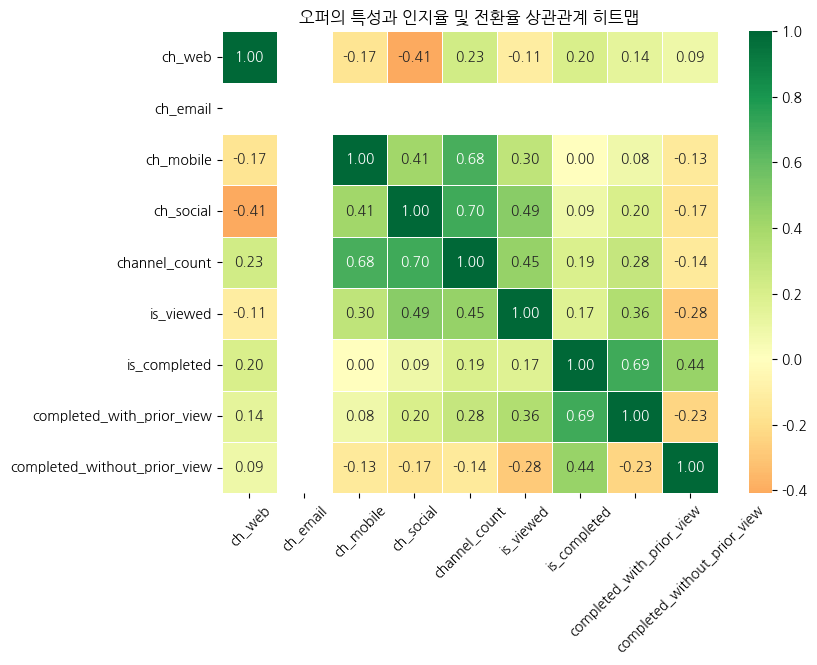

In [459]:
import seaborn as sns

ch_correlation = df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'is_viewed',
                 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
# 히트맵 (전체적인 상관관계 파악)

plt.figure(figsize=(8, 6))
sns.heatmap(ch_correlation, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('오퍼의 특성과 인지율 및 전환율 상관관계 히트맵')
plt.xticks(rotation=45)
plt.show() 

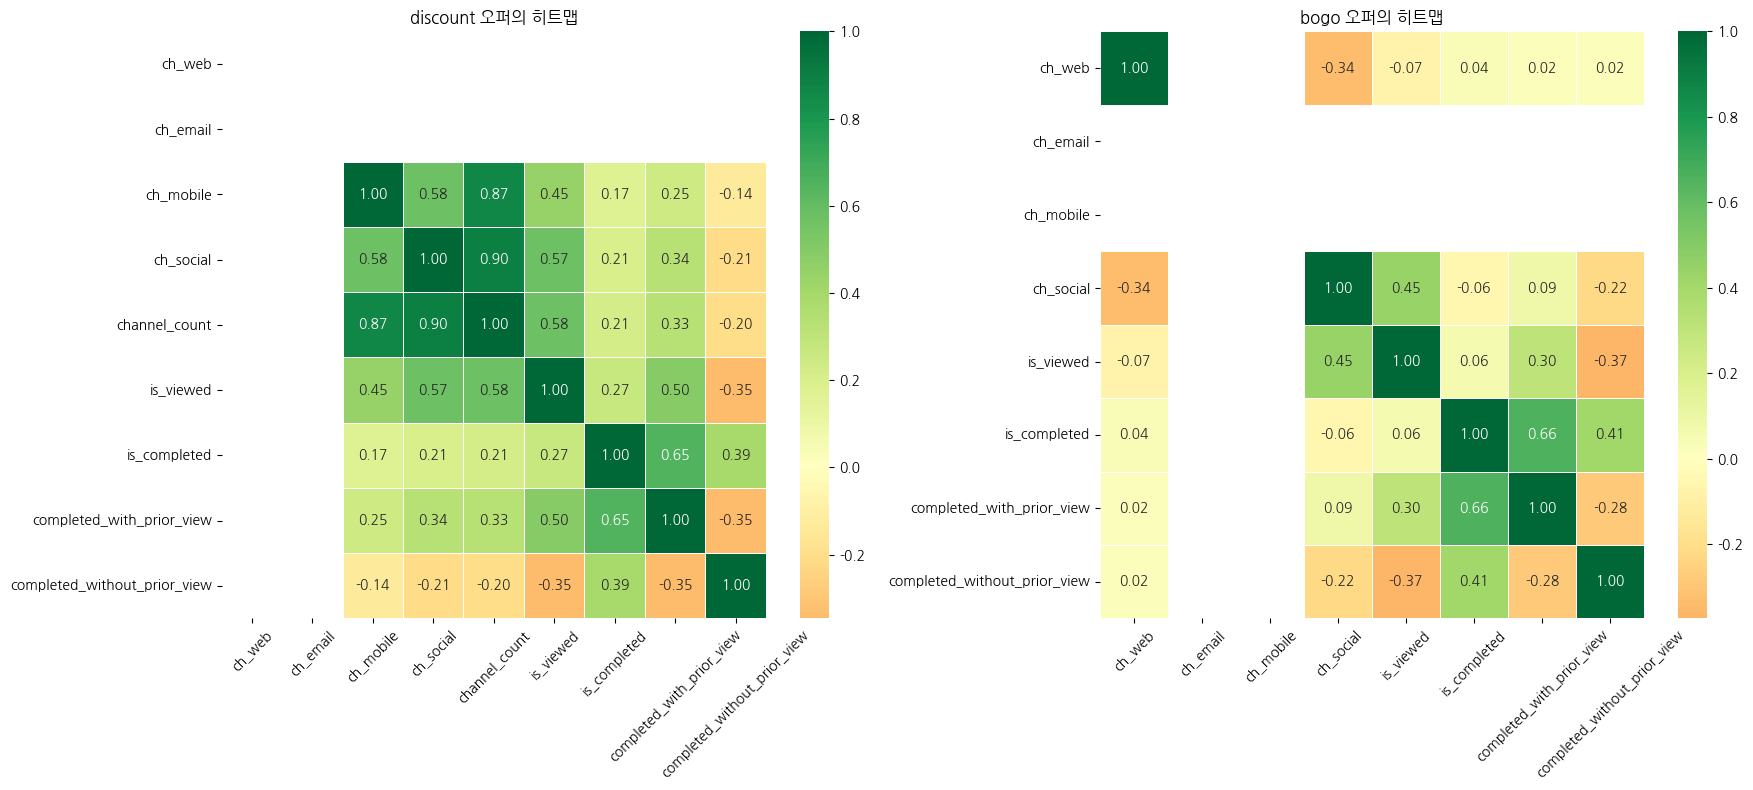

In [460]:
# bogo, discount의 지표 히트맵 시각화
import seaborn as sns

discount_df = df2[df2['offer_type']=='discount']
bogo_df = df2[df2['offer_type']=='bogo']

discount_corr = discount_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'is_viewed',
                 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
bogo_corr = bogo_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'is_viewed',
                 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
ax2 = axes[1]
label = ['discount', 'bogo']

sns.heatmap(discount_corr, ax=ax1, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
sns.heatmap(bogo_corr, ax=ax2, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

ax1.set_title(f"{label[0]} 오퍼의 히트맵")
ax2.set_title(f"{label[1]} 오퍼의 히트맵")

plt.tight_layout()
plt.show()

In [461]:
# 특히 다음과 같이 상관관계 히트맵을 그려보았을 때 채널이 모두 활용된 경우엔 빈칸으로 되어 있기 때문에
# 완료율, 인지완료율등의 지표를 분석하기 위해서는 채널별로 구분하는 것 뿐만 아니라 오퍼 타입을 구분하여 분석할 필요가 있었다.

In [ ]:
# duration의 차이에 따른 완료율 영향력 
# 오퍼 타입 별 duration의 차이에 따른

### 오퍼타입별 분석

### 오퍼간격별 분석